### Import and Data Visulisation

In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import simpest
from simpest.models.simplace import (
    SimplaceConfig, init_simplace, run_simplace, get_project_row,
    export_crop_model_data, convert_weather, build_management,
    merge_simplace_and_franchestyn, getSimplaceDirectories
    )
from simpest.models.franchestyn import (FranchestynConfig,run_franchestyn,build_season_summary,
                                        save_simulation_results_csv,save_season_summary_csv,
                                        save_calibrated_parameters_csv,)

In [ ]:
path_weather = './../../../simpest_data/SimulationExperimentTemplate/data/weather/indiana.txt'
path_weather_f = './../../../simpest_data/SimulationExperimentTemplate/data/weather/weather_indiana_f.txt'
path_reference_f = 'C:/ParamVC/Research/simplace+/FRA_REFERENCE_Indiana.csv'


SIMPLACE_INSTALL = 'C:/ParamVC/Research/simplace+/simplace_portable/workspace/'
SIMPLACE_WORK = 'C:/ParamVC/Research/simplace+/simplace_portable/workspace/simplace_run/simulation/'
SOLUTION_PATH = 'SimulationExperimentTemplate/solution/Lintul5_indiana.sol.xml'
PROJECT_PATH = 'SimulationExperimentTemplate/project/Lintul5All_indiana.proj.xml'
SIMPLACE_OUT = './../../../simpest_data/simpest_outputs/' #'C:/ParamVC/Research/simplace+/simplace_out/'




# INPUTS
PROJECT_LINES = [1]

# FraNchEstYN Python runner config
FRANCH_CROP_TYPE = 'wheat'
FRANCH_DISEASE_TYPE = 'septoria'
FRANCH_FUNGICIDE_TYPE = None #'protectant'
FRANCH_SITE = 'indiana'
FRANCH_VARIETY = 'Generic'
FRANCH_DISEASE = 'thisDisease'
FRANCH_LATITUDE = 40.5
FRANCH_IS_CALIBRATION = True
FRANCH_CALIBRATION_VARIABLE = 'disease' # 'all'  # 'crop', 'disease', or 'all'
FRANCH_USE_GDD = False  # True: use GDD-based cycle percentage; False: match C# calendar-based cycle percentage
FRANCH_N_RESTARTS = 1
FRANCH_MAX_ITER = 1


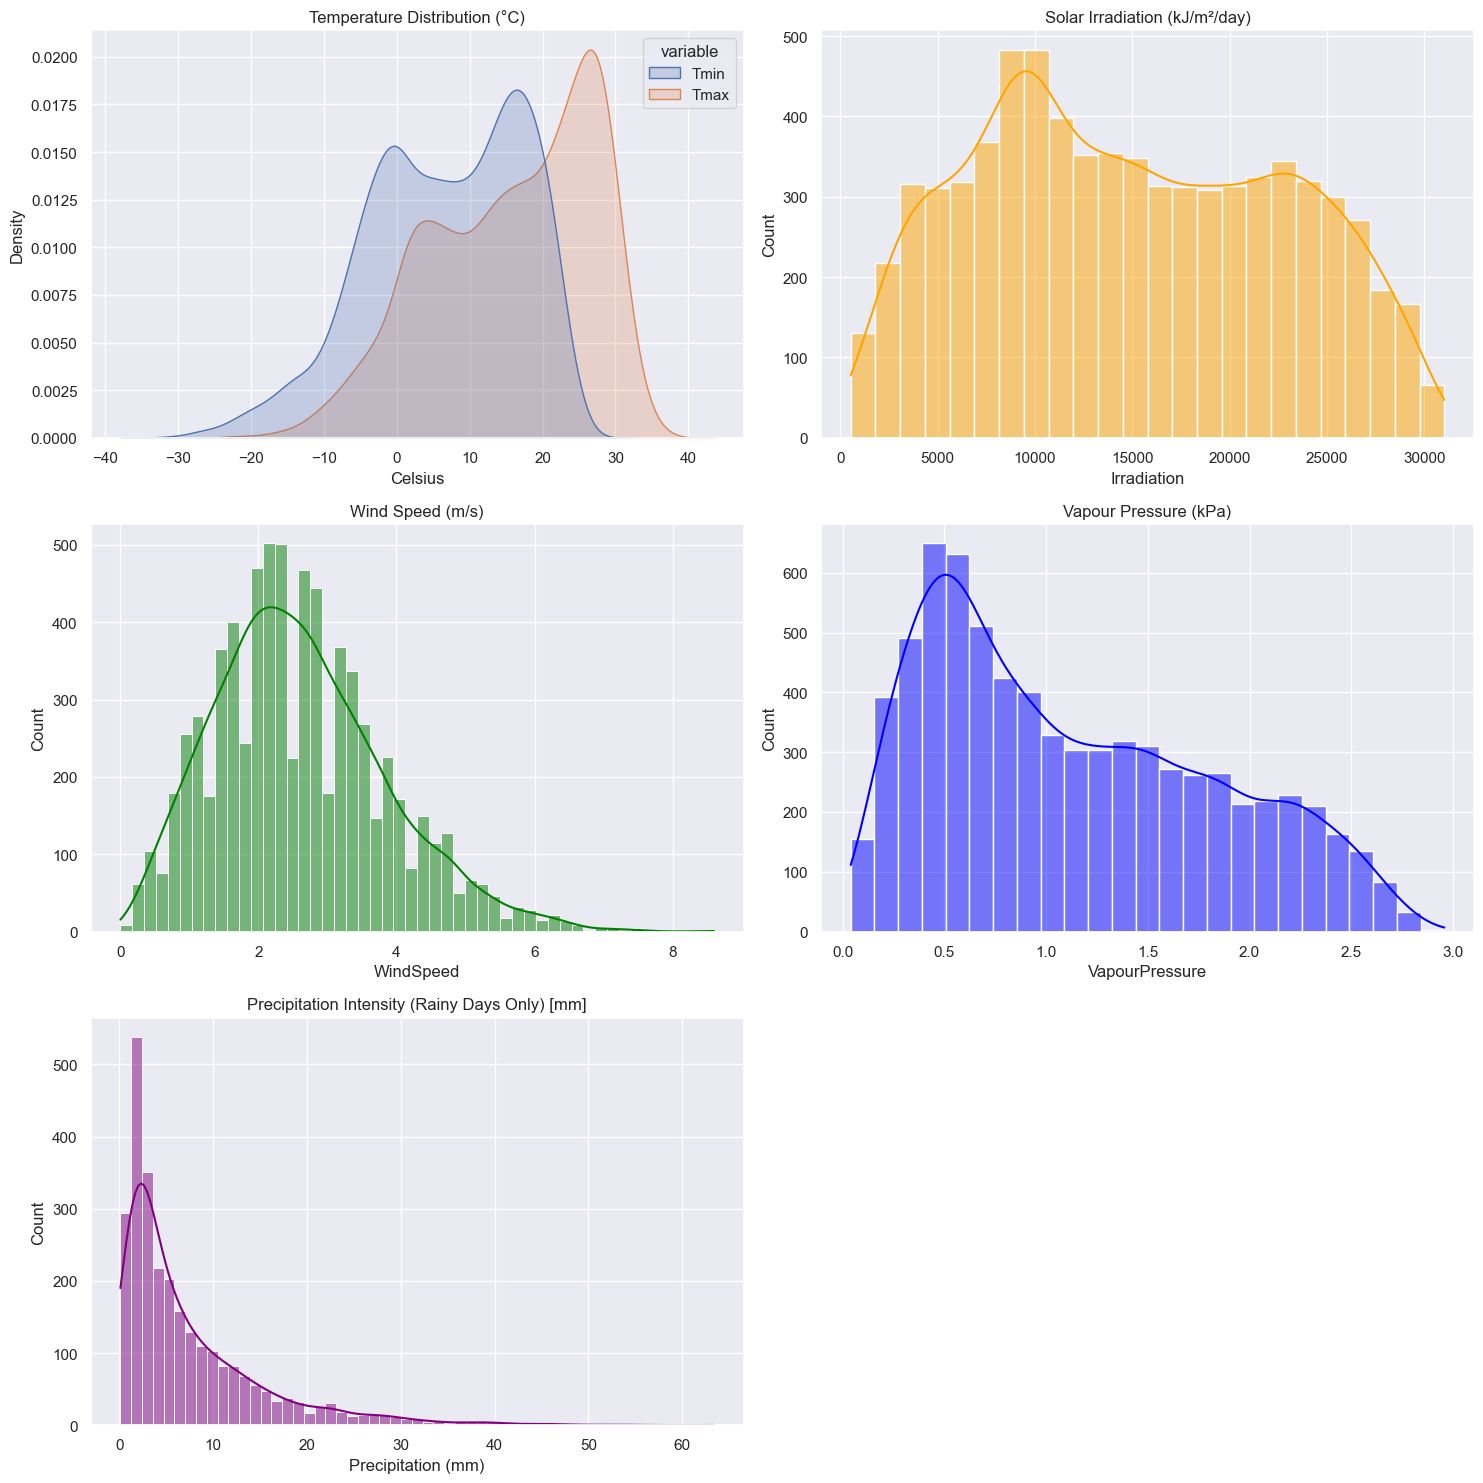

In [3]:
# Load the data
df_final = pd.read_csv(path_weather, sep='\t')
# Ensure the date column is recognized as a datetime object
df_final['date'] = pd.to_datetime(df_final['CURRENTDAY'], dayfirst=True)

# --- STEP 2: VISUALIZATION ---
sns.set_theme()
# Increased to 3 rows to accommodate the 5th variable
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# 1. Temperature Distribution (Tmin vs Tmax)
df_temp = df_final.melt(id_vars='CURRENTDAY', value_vars=['Tmin', 'Tmax'])
sns.kdeplot(data=df_temp, x='value', hue='variable', fill=True, ax=axes[0, 0])
axes[0, 0].set_title('Temperature Distribution (°C)')
axes[0, 0].set_xlabel('Celsius')

# 2. Irradiation Distribution
sns.histplot(df_final['Irradiation'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Solar Irradiation (kJ/m²/day)')

# 3. Wind Speed Distribution
sns.histplot(df_final['WindSpeed'], kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Wind Speed (m/s)')

# 4. Vapour Pressure Distribution
sns.histplot(df_final['VapourPressure'], kde=True, color='blue', ax=axes[1, 1])
axes[1, 1].set_title('Vapour Pressure (kPa)')

# 5. Precipitation Distribution (NEW)
# We filter for values > 0 to see the distribution of rainfall events more clearly,
# as zero-rain days usually dominate the dataset.
rainy_days = df_final[df_final['Precipitation'] > 0]['Precipitation']
sns.histplot(rainy_days, kde=True, color='purple', ax=axes[2, 0])
axes[2, 0].set_title('Precipitation Intensity (Rainy Days Only) [mm]')
axes[2, 0].set_xlabel('Precipitation (mm)')

# 6. Hide the empty subplot (optional)
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

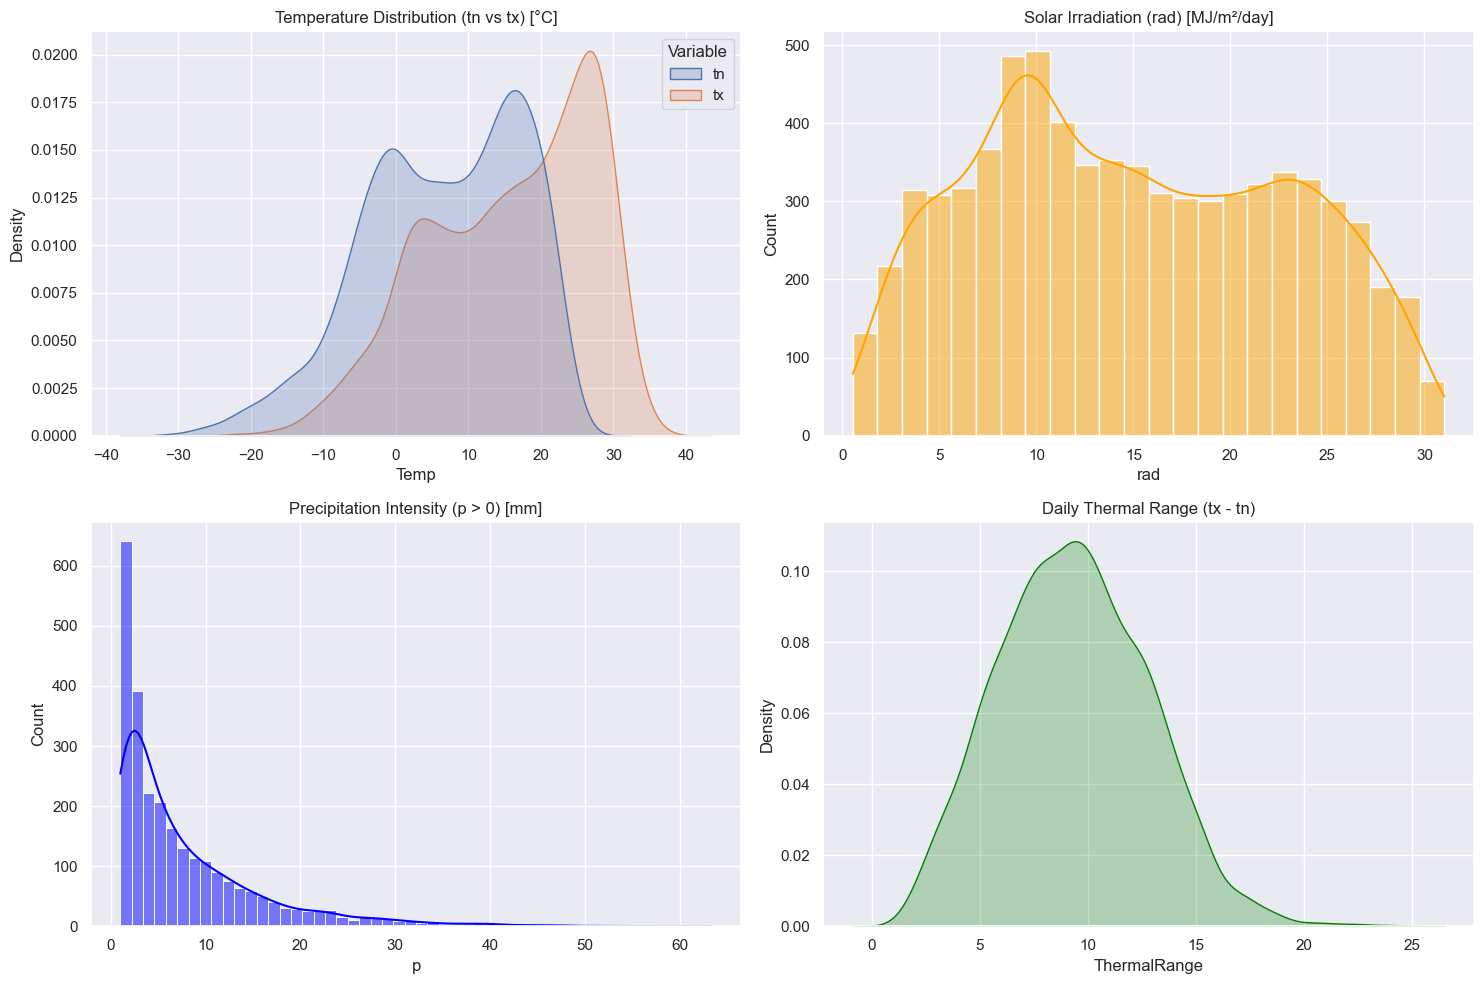

In [4]:
# 1. Load the "f" file (Comma-separated)
df_f = pd.read_csv(path_weather_f)

# 2. Create the date columns
df_f['date'] = pd.to_datetime(df_f[['year', 'month', 'day']])
df_f['DayOfYear'] = df_f['date'].dt.dayofyear

# --- PART 1: DISTRIBUTION PLOTS ---
sns.set_theme()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Temperature Distribution (tn = min, tx = max)
df_temp = df_f.melt(id_vars='date', value_vars=['tn', 'tx'], var_name='Variable', value_name='Temp')
sns.kdeplot(data=df_temp, x='Temp', hue='Variable', fill=True, ax=axes[0, 0])
axes[0, 0].set_title('Temperature Distribution (tn vs tx) [°C]')

# Irradiation Distribution (rad)
sns.histplot(df_f['rad'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Solar Irradiation (rad) [MJ/m²/day]')

# Precipitation Distribution (p)
sns.histplot(df_f[df_f['p'] > 0]['p'], kde=True, color='blue', ax=axes[1, 0])
axes[1, 0].set_title('Precipitation Intensity (p > 0) [mm]')

# Daily Thermal Range (Difference between max and min)
df_f['ThermalRange'] = df_f['tx'] - df_f['tn']
sns.kdeplot(df_f['ThermalRange'], fill=True, color='green', ax=axes[1, 1])
axes[1, 1].set_title('Daily Thermal Range (tx - tn)')

plt.tight_layout()
plt.show()


### Run Simplace

In [ ]:
# Build model configs from INPUTS above
# import importlib
# import simpest.models.franchestyn as _fr_mod

# Ensure notebook uses the latest FranchestynConfig definition from disk
# importlib.reload(_fr_mod)
# FranchestynConfig = _fr_mod.FranchestynConfig

sp_cfg = SimplaceConfig(
    install_dir=SIMPLACE_INSTALL, work_dir=SIMPLACE_WORK, output_dir=SIMPLACE_OUT,
    solution_path=SOLUTION_PATH, project_path=PROJECT_PATH,
    )


# Stage 1: Run SIMPLACE only
shell = init_simplace(sp_cfg)
run_simplace(shell, sp_cfg, project_lines=PROJECT_LINES)

dirs = getSimplaceDirectories(shell)
work_root = Path(dirs["_WORKDIR_"])
output_root = Path(dirs["_OUTPUTDIR_"])
selected_line = PROJECT_LINES[0]
project_row = get_project_row(work_root, selected_line=selected_line)
simplace_daily_path = output_root / "SimulationExperimentTemplate" / f"{project_row['location']}{project_row['iopt']}_daily.csv"
start_year = int(project_row["startdate"].split(".")[-1])
end_year = int(project_row["enddate"].split(".")[-1])
print('SIMPLACE completed')
print('SIMPLACE daily output:', simplace_daily_path)

# Visualize SIMPLACE outputs (run after Stage 1)
sim_df = pd.read_csv(simplace_daily_path, sep=';')
sim_df['date'] = pd.to_datetime(sim_df['CURRENT.DATE'], format='%d.%m.%Y')
sim_df['TAGB'] = pd.to_numeric(sim_df['TAGB'], errors='coerce')
sim_df['WSO'] = pd.to_numeric(sim_df['WSO'], errors='coerce')

SIMPLACE completed
SIMPLACE daily output: ..\..\..\simpest_data\simpest_outputs\SimulationExperimentTemplate\indiana4_daily.csv


### SImplace Visualisation

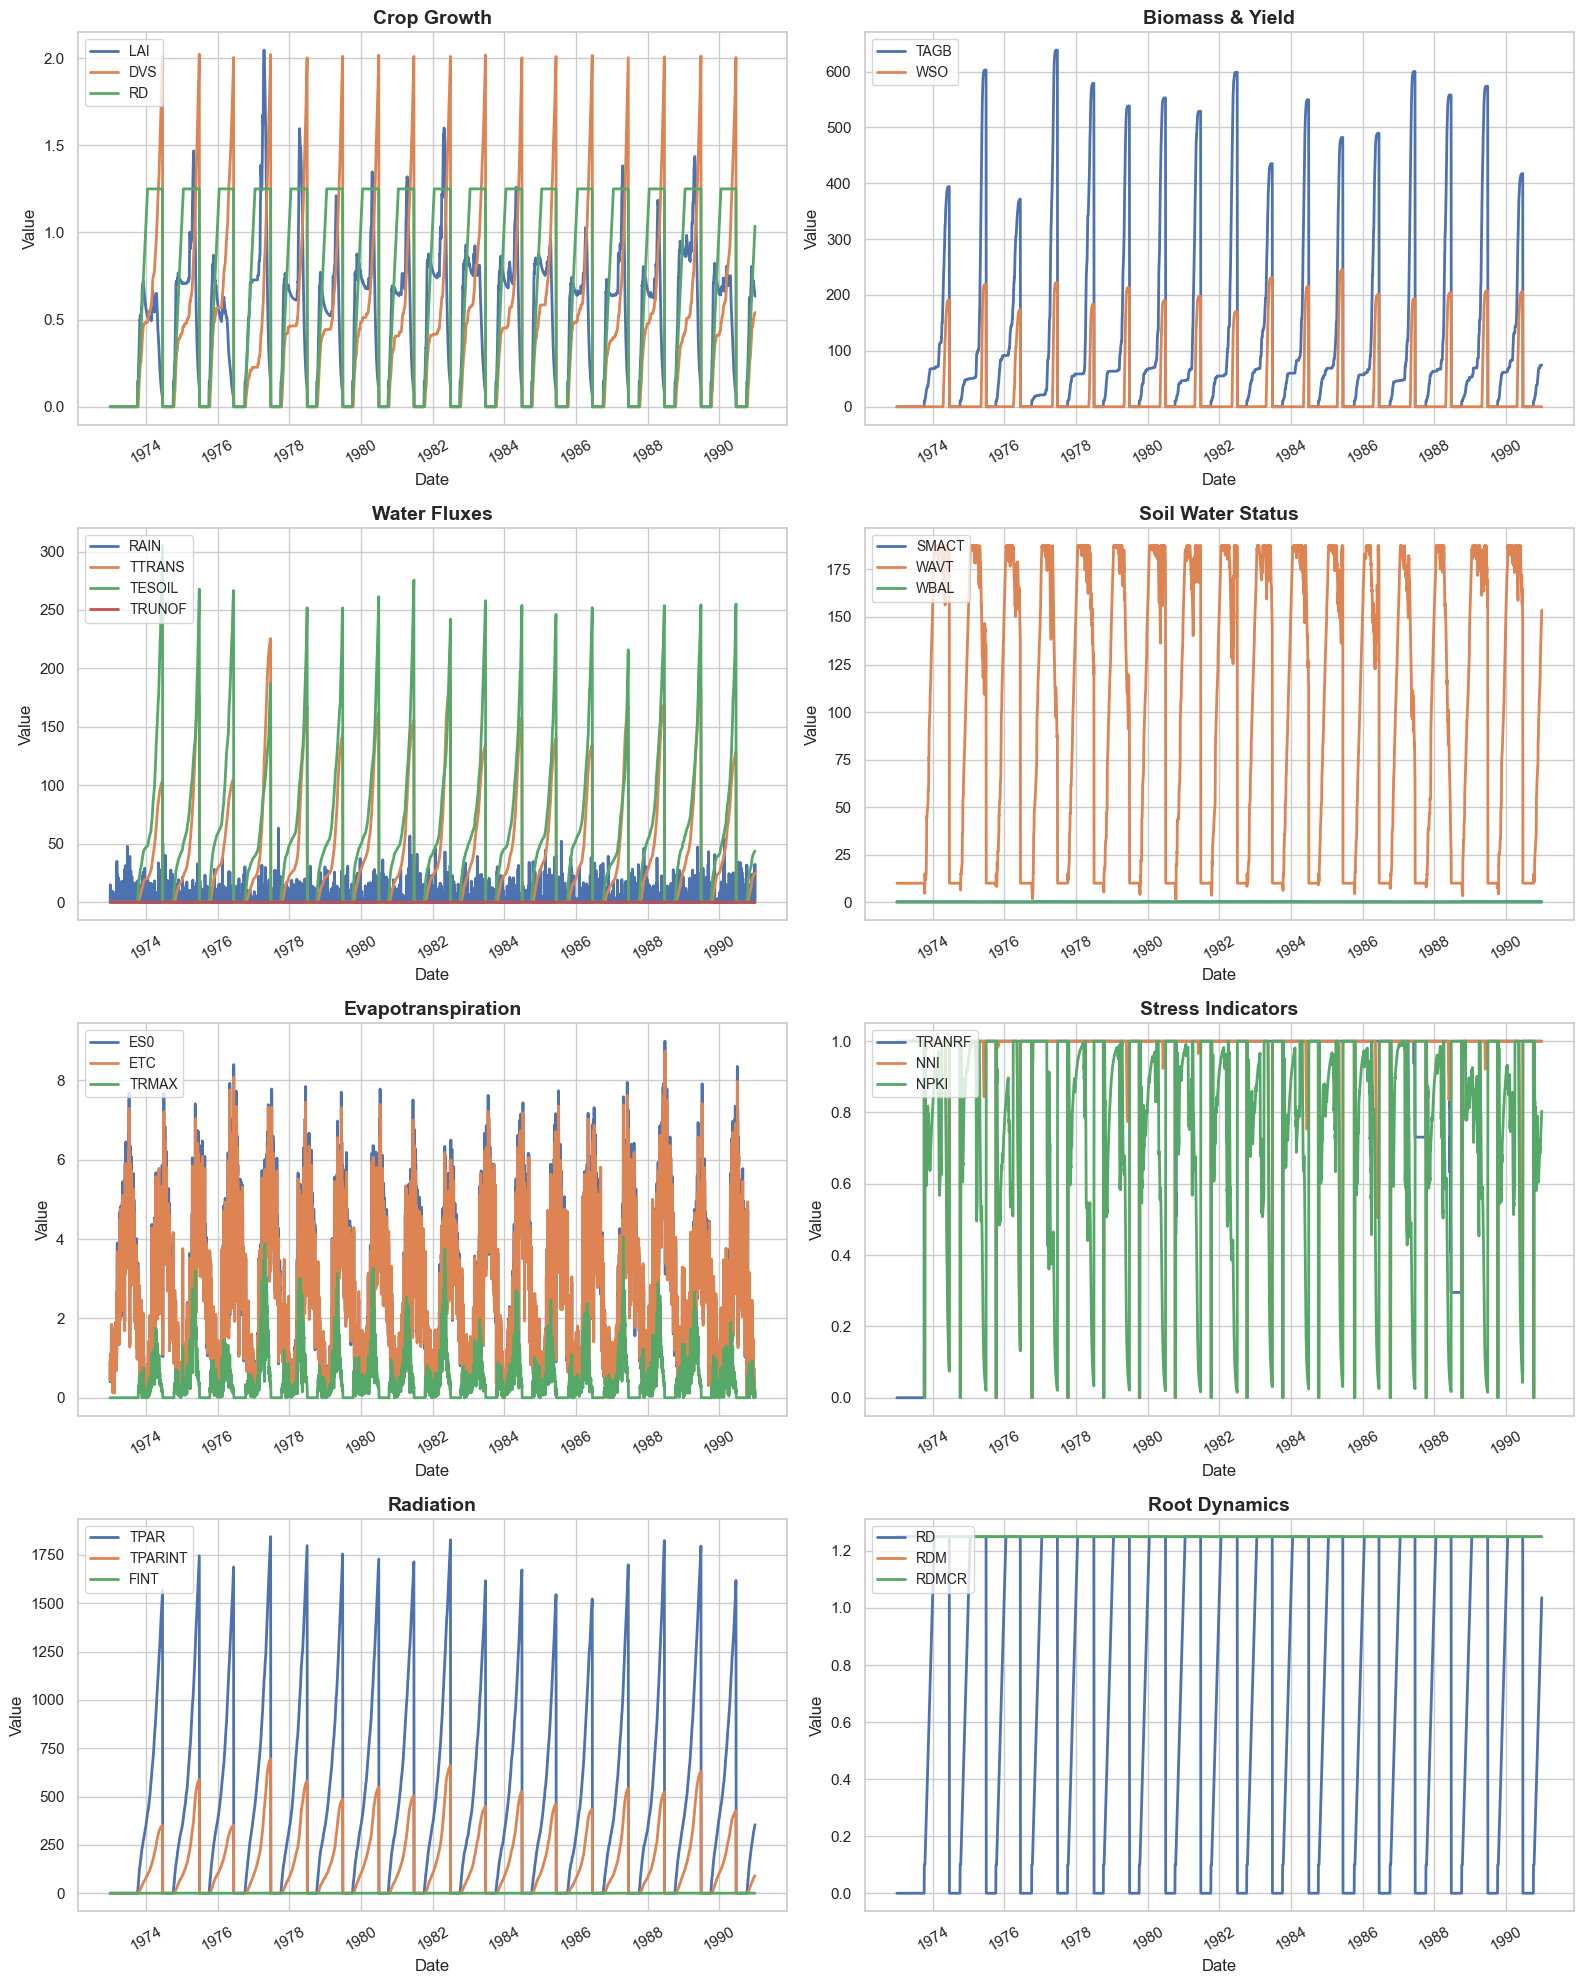

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------
# Load data (using your file path logic)
# ---------------------------------------------------
df = sim_df.copy()

# Convert date column - Update column name if it is 'CURRENTDAY' or 'CURRENT.DATE'
df["date"] = pd.to_datetime(df["CURRENT.DATE"], dayfirst=True)

# ---------------------------------------------------
# Define Variable Groups
# ---------------------------------------------------
groups = [
    ("Crop Growth", ["LAI", "DVS", "RD"]),
    ("Biomass & Yield", ["TAGB", "WSO"]),
    ("Water Fluxes", ["RAIN", "TTRANS", "TESOIL", "TRUNOF"]),
    ("Soil Water Status", ["SMACT", "WAVT", "WBAL"]),
    ("Evapotranspiration", ["ES0", "ETC", "TRMAX"]),
    ("Stress Indicators", ["TRANRF", "NNI", "NPKI"]),
    ("Radiation", ["TPAR", "TPARINT", "FINT"]),
    ("Root Dynamics", ["RD", "RDM", "RDMCR"])
]

# ---------------------------------------------------
# Create the 2-column Multi-row Figure
# ---------------------------------------------------
sns.set_theme(style="whitegrid")
n_groups = len(groups)
n_cols = 2
n_rows = (n_groups + 1) // n_cols  # Calculates rows needed for 2 columns

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()  # Flatten to easily iterate

for i, (title, variables) in enumerate(groups):
    ax = axes[i]
    
    # Plot each variable in the group
    for var in variables:
        if var in df.columns:
            sns.lineplot(data=df, x="date", y=var, ax=ax, label=var, linewidth=2)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend(loc='upper left', fontsize='small')
    
    # Rotate date labels for better readability
    plt.setp(ax.get_xticklabels(), rotation=30)

# Remove any empty subplots if the number of groups is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Configure simplace data for franchestyne

In [7]:
fr_cfg = FranchestynConfig(
    reference_path=path_reference_f,
    crop_type=FRANCH_CROP_TYPE,
    disease_type=FRANCH_DISEASE_TYPE,
    fungicide_type=FRANCH_FUNGICIDE_TYPE,
    site=FRANCH_SITE,
    variety=FRANCH_VARIETY,
    disease=FRANCH_DISEASE,
    is_calibration=FRANCH_IS_CALIBRATION,
    calibration_variable=FRANCH_CALIBRATION_VARIABLE,
    use_gdd=FRANCH_USE_GDD,
    n_restarts=FRANCH_N_RESTARTS,
    max_iter=FRANCH_MAX_ITER,
 )

crop_model_path = export_crop_model_data(output_root, project_row)
weather_path = convert_weather(work_root, output_root, project_row["location"])
management_path = build_management(output_root, project_row)

### Run and visualise Franchestyne

In [8]:
mgmt = pd.read_csv(management_path)
print("Management columns:", mgmt.columns.tolist())
# print(mgmt[['site', 'variety', 'sowingdoy', 'year']])
treatment_cols = [c for c in mgmt.columns if 'treatment' in c.lower()]
print(f"Treatment columns found: {treatment_cols}")
if treatment_cols:
    print(mgmt[treatment_cols].head())
else:
    print("⚠️  No treatment columns found—fungicide will remain inactive.")

Management columns: ['site', 'crop', 'variety', 'year', 'sowingDOY']
Treatment columns found: []
⚠️  No treatment columns found—fungicide will remain inactive.


In [9]:
# Stage 2: Run FraNchEstYN using SIMPLACE-generated inputs
result = run_franchestyn(
    weather_path=str(weather_path),
    management_path=str(management_path),
    start_year=start_year,
    end_year=end_year,
    config=fr_cfg,
    cropmodel_path=str(crop_model_path),
)

summary = result['outputs']['summary']
simulation = result['outputs']['simulation']

save_simulation_results_csv(simulation, output_root)
simulation_df = pd.DataFrame(simulation)
season_summary = build_season_summary(simulation_df, site=fr_cfg.site, variety=fr_cfg.variety)
save_season_summary_csv(season_summary, output_root)

best_params = summary.get('best_params', {}) if isinstance(summary, dict) else {}
save_calibrated_parameters_csv(best_params, output_root, site=fr_cfg.site, variety=fr_cfg.variety)
merged_path = merge_simplace_and_franchestyn(output_root, project_row, simulation_df)

print('FraNchEstYN completed')
print('Merged output:', merged_path)
print('RMSE:', summary.get('rmse'))

Parsed row: site=indiana, variety=generic, sow_doy=280, fung_doys=[]
- Calibrating 19 using Nelder-Mead method. 
-Parameters: 
['disease_OuterInoculumMax', 'disease_PathogenSpread', 'disease_WetnessDurationOptimum', 'disease_WetnessDurationMinimum', 'disease_DryCriticalInterruption', 'disease_Tmin', 'disease_Topt', 'disease_Tmax', 'disease_RelativeHumidityCritical', 'disease_Rain50Detachment', 'disease_RelativeHumidityNotLimiting', 'disease_HydroThermalTimeOnset', 'disease_CyclePercentageOnset', 'disease_LatencyDuration', 'disease_SporulationDuration', 'disease_LightStealerDamage', 'disease_RUEreducerDamage', 'disease_AssimilateSappersDamage', 'disease_OuterInoculumShapeParameter']
Run 10/10 Iteration 199/200 CURR RMSE=28.9010
Best RMSE: 27.8190
FraNchEstYN completed
Merged output: ..\..\..\simpest_data\simpest_outputs\SimulationExperimentTemplate\merged_simulation_data.csv
RMSE: 27.819


In [10]:
# Final output tables (after Stage 2)
merged = pd.read_csv(merged_path)
summary_df = pd.read_csv(output_root / 'SimulationExperimentTemplate' / 'franchestyn_season_summary.csv')

print('Merged shape:', merged.shape)
print('Summary shape:', summary_df.shape)
# display(merged.head())
# display(summary_df)

Merged shape: (6574, 84)
Summary shape: (18, 18)


Loaded 111 reference disease points across seasons: ['1972/1973', '1973/1974', '1974/1975', '1975/1976', '1976/1977', '1977/1978', '1978/1979', '1979/1980', '1980/1981', '1981/1982', '1982/1983', '1983/1984', '1984/1985', '1985/1986', '1986/1987', '1987/1988', '1988/1989', '1989/1990', '1990/1991']


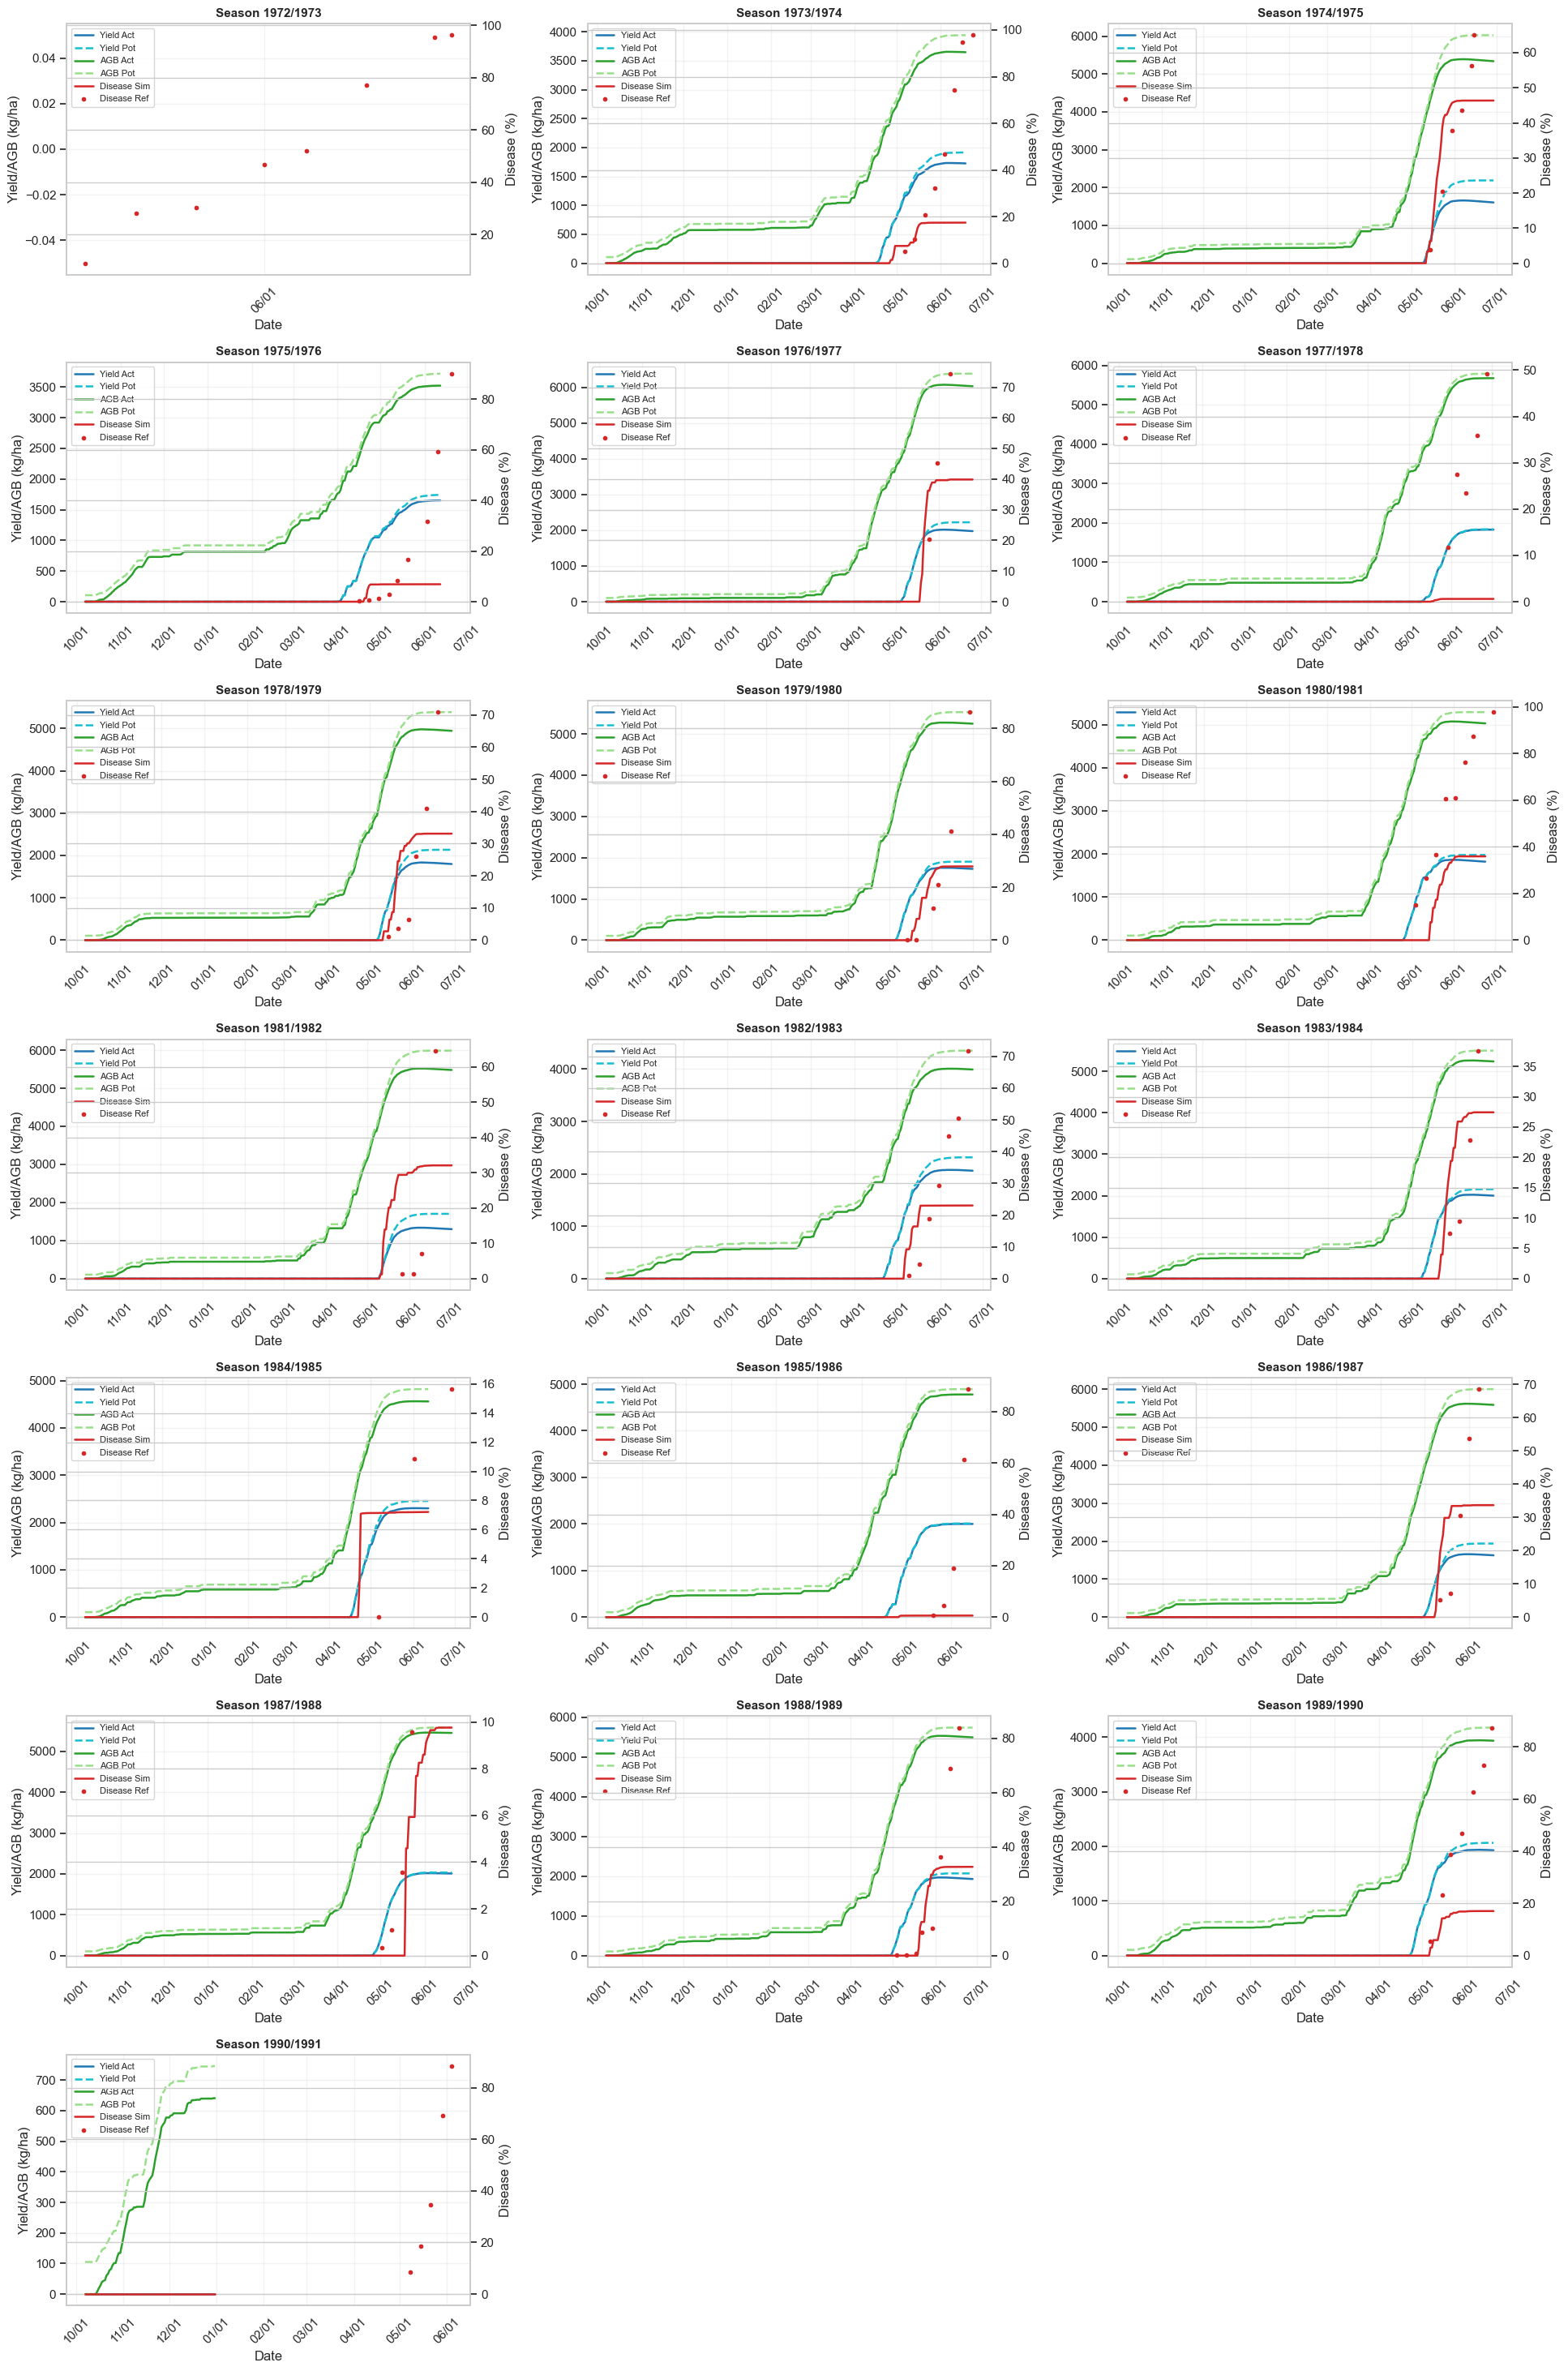

In [11]:
# Plot one figure with season panels arranged in 3 columns per row (Oct -> Jul seasons) + reference overlay
import math
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from pathlib import Path
import numpy as np

if 'merged' not in globals():
    raise ValueError('Run Stage 2 and the Final output tables cell first to create `merged`.')

# Load reference disease data
ref_df = None
ref_disease_by_season = {}
try:
    ref_path = Path(path_reference_f)
    if ref_path.exists():
        ref_df = pd.read_csv(ref_path)
        
        # Filter by site (case-insensitive) and variety
        if 'sName' in ref_df.columns:
            ref_df = ref_df[ref_df['sName'].str.lower() == FRANCH_SITE.lower()]
        if 'variety' in ref_df.columns:
            ref_df = ref_df[ref_df['variety'] == FRANCH_VARIETY]
        
        # Filter to rows with disease data
        ref_df = ref_df[ref_df[FRANCH_DISEASE].notna()].copy()
        
        if len(ref_df) > 0:
            # Map DOY + year to date
            ref_df['date'] = pd.to_datetime(ref_df['year'].astype(str) + 
                                            ref_df['DOY'].astype(str), 
                                            format='%Y%j', errors='coerce')
            
            # Determine season for each reference point (Oct-Dec = current year season; Jan-Jul = previous year season)
            ref_df['season_start_year'] = ref_df['date'].dt.year.where(
                ref_df['date'].dt.month >= 10, 
                ref_df['date'].dt.year - 1
            )
            ref_df['season_label'] = (ref_df['season_start_year'].astype(str) + '/' + 
                                      (ref_df['season_start_year'] + 1).astype(str))
            
            # Group by season
            for season, group in ref_df.groupby('season_label'):
                ref_disease_by_season[season] = group[[
                    'date', FRANCH_DISEASE
                ]].copy()
                ref_disease_by_season[season].columns = ['date', 'ref_disease']
        
        print(f"Loaded {len(ref_df)} reference disease points across seasons: {list(ref_disease_by_season.keys())}")
except Exception as e:
    print(f"Warning: Could not load reference data: {e}")

df = merged.copy()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).sort_values('date')

# Keep only Oct..Jul window
df = df[df['date'].dt.month.isin([10, 11, 12, 1, 2, 3, 4, 5, 6, 7])].copy()

# Season label: Oct-Dec belong to current year; Jan-Jul belong to previous-year season
df['season_start_year'] = df['date'].dt.year.where(df['date'].dt.month >= 10, df['date'].dt.year - 1)
df['season_label'] = df['season_start_year'].astype(str) + '/' + (df['season_start_year'] + 1).astype(str)

def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

yield_act_col = pick_col(['YieldActual_F_kg_ha', 'YieldActual_F', 'YieldActual'])
yield_pot_col = pick_col(['YieldAttainable_F_kg_ha', 'YieldAttainable_F', 'YieldAttainable'])
agb_act_col = pick_col(['AGBactual_F', 'AGBactual'])
agb_pot_col = pick_col(['AGBattainable_F', 'AGBattainable'])
disease_col = pick_col(['DiseaseSeverity_F', 'DiseaseSeverity'])

missing = [
    ('actual yield', yield_act_col),
    ('potential yield', yield_pot_col),
    ('actual AGB', agb_act_col),
    ('potential AGB', agb_pot_col),
    ('disease severity', disease_col),
]
missing = [name for name, col in missing if col is None]
if missing:
    raise ValueError(f'Missing required columns for plotting: {missing}')

season_groups = [(s, g.sort_values('date').copy()) for s, g in df.groupby('season_label', sort=True)]
if not season_groups:
    raise ValueError('No data available in Oct-Jul window for plotting.')

n_cols = 3
n_rows = math.ceil(len(season_groups) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.5 * n_cols, 4.2 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (season, g) in enumerate(season_groups):
    ax1 = axes_flat[i]
    ax2 = ax1.twinx()

    disease_series = pd.to_numeric(g[disease_col], errors='coerce')
    if disease_series.dropna().size > 0 and disease_series.dropna().max() <= 1.0:
        disease_series = disease_series * 100.0

    ax1.plot(g['date'], pd.to_numeric(g[yield_act_col], errors='coerce'), label='Yield Act', color='#1f77b4', linewidth=1.8)
    ax1.plot(g['date'], pd.to_numeric(g[yield_pot_col], errors='coerce'), label='Yield Pot', color='#17becf', linewidth=1.8, linestyle='--')
    ax1.plot(g['date'], pd.to_numeric(g[agb_act_col], errors='coerce'), label='AGB Act', color='#2ca02c', linewidth=1.8)
    ax1.plot(g['date'], pd.to_numeric(g[agb_pot_col], errors='coerce'), label='AGB Pot', color='#98df8a', linewidth=1.8, linestyle='--')
    ax2.plot(g['date'], disease_series, label='Disease Sim', color='#d62728', linewidth=1.8)

    # Overlay reference disease points if available for this season
    if season in ref_disease_by_season:
        ref_season = ref_disease_by_season[season]
        if len(ref_season) > 0:
            ref_disease_vals = pd.to_numeric(ref_season['ref_disease'], errors='coerce')
            # Convert to percentage if values are 0-1
            if ref_disease_vals.max() <= 1.0:
                ref_disease_vals = ref_disease_vals * 100.0
            ax2.scatter(ref_season['date'], ref_disease_vals, 
                       marker='.', color='#d62728', s=10, linewidths=2.5, 
                       label='Disease Ref', zorder=10)

    ax1.set_title(f'Season {season}', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Yield/AGB (kg/ha)')
    ax2.set_ylabel('Disease (%)')
    ax1.grid(True, alpha=0.25)
    
    # Format x-axis with date ticks
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
    ax1.tick_params(axis='x', rotation=45)

    l1, t1 = ax1.get_legend_handles_labels()
    l2, t2 = ax2.get_legend_handles_labels()
    ax1.legend(l1 + l2, t1 + t2, loc='upper left', fontsize=8, frameon=True)

# Hide unused subplot panels
for j in range(len(season_groups), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()